# Nonparametric Permutation Test of Spatial Dependence.

In [1]:
%run -i ~/project/preambles
%run -i ~/project/helper_functions
%run -i ~/project/fitting_functions

cpu


In [2]:
puck_list = 'all'
gene_list = [ "Inha", "Inhba", "Inhbb", "Fst"]
head = 1000
adata, X, Y, df=load_data(gene_list=gene_list, head=head, puck_list = puck_list)
X

tensor([[ 0.3740, -0.0371],
        [-0.3654, -0.1786],
        [-0.0494,  0.0648],
        ...,
        [ 0.0543, -0.0238],
        [-0.0650,  0.0154],
        [-0.2391,  0.1645]], dtype=torch.float64)

In [16]:
adata.obs.columns.tolist()

['n_genes',
 'n_genes_by_counts',
 'total_counts',
 'total_counts_mt',
 'pct_counts_mt',
 'puck',
 'Age',
 'n_counts',
 'leiden',
 'leiden_12',
 'cell_type',
 'leiden_15',
 'new_annot',
 'is_oocyte',
 'id_oocyte',
 'is_granulosa',
 'granulosa_type',
 'id_follicle',
 'id_corpusluteum',
 'id_proximity_oocyte',
 'id_proximity_follicle',
 'id_proximity_corpusluteum',
 'is_theca',
 'id_theca',
 'is_mesenchyme',
 'id_mesenchyme',
 'is_immune',
 'id_immune',
 'stromal_immune',
 'is_vascular',
 'id_vascular',
 'stromal_vascular',
 'is_epithelium',
 'id_epithelium',
 'is_primordial',
 'id_primordial',
 'oocyte_label',
 'new_annot_foll',
 'tissue',
 'mouse',
 'stage',
 'batch',
 'id_oocyte_matched',
 'segment_id',
 'segment_id_extended',
 'segment_layer',
 'segment_layer_extended',
 'segment_has_oocyte',
 'segment_label',
 'segment_label_coarse',
 'segment_type',
 'MNGC',
 'is_contaminant',
 'new_annot_foll_precontamination',
 'id_oocyte_precontamination',
 'id_oocyte_matched_precontamination',


In [18]:
adata.obs['new_annot_foll']

GACTAACNTGATCA-1-0         Luteal - early
GTCGCCCNTAAAGG-1-0                 Oocyte
TCCGAACTTGGTGG-1-0                 Oocyte
GTAGAGGACNTAAG-1-0                 Muscle
TAGNGCAGGGCTCC-1-0                 Oocyte
                             ...         
GGTTCCGCTGGTCG-1-1                Stromal
AATANCACTAACTG-1-1            Endothelial
ATAGGATTGCAGGT-1-1                 Immune
GGCTAATCGGCACC-1-1    GC - antral mitotic
TAATAATTTTCCGT-1-1             Epithelial
Name: new_annot_foll, Length: 201657, dtype: category
Categories (16, object): ['Cumulus - oocyte', 'Endothelial', 'Epithelial', 'GC - antral early mitotic', ..., 'Oocyte', 'Oocyte - contaminated', 'Stromal', 'Theca']

In [17]:
adata.obs['new_annot_foll'][adata.obs['new_annot_foll'] == "GC - atretic"]

TAGTCACCTCCCAC-1-0    GC - atretic
AGGAGGGCTGCACT-1-0    GC - atretic
TTGAGCGTTGCGAC-1-0    GC - atretic
CTTNCAAAAGACTT-1-0    GC - atretic
NATAGTNAGTAGGA-1-0    GC - atretic
                          ...     
GGTATCAACTAAAC-1-1    GC - atretic
TCAGGGGATAACAT-1-1    GC - atretic
TCCCAATCAGCTCA-1-1    GC - atretic
GCAGTNAGGGCACG-1-1    GC - atretic
AGCCGGTCCTCTAA-1-1    GC - atretic
Name: new_annot_foll, Length: 6095, dtype: category
Categories (16, object): ['Cumulus - oocyte', 'Endothelial', 'Epithelial', 'GC - antral early mitotic', ..., 'Oocyte', 'Oocyte - contaminated', 'Stromal', 'Theca']

In [3]:
Y

tensor([[0.0000, 0.0000, 0.0000, 0.0000],
        [0.7538, 2.2487, 0.6911, 0.0000],
        [0.0000, 0.0000, 0.0000, 0.0000],
        ...,
        [0.3771, 0.0000, 0.0000, 0.0000],
        [0.0000, 0.0000, 0.0000, 0.0000],
        [0.0000, 0.0000, 0.0000, 0.0000]], dtype=torch.float64)

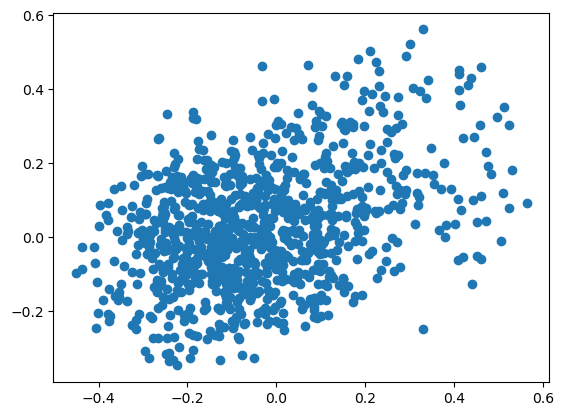

In [18]:
plt.scatter(X[:,0], X[:,1])

(array([[177., 348., 258., ...,   4.,   0.,   0.],
        [176., 379., 248., ...,   0.,   0.,   0.],
        [146., 308., 285., ...,   2.,   0.,   0.],
        ...,
        [ 28.,  98., 230., ...,  31.,  15.,   2.],
        [ 21.,  62., 100., ...,  44.,   2.,   0.],
        [109., 297., 343., ...,   0.,   0.,   0.]]),
 array([0.        , 0.1117649 , 0.2235298 , 0.3352947 , 0.4470596 ,
        0.5588245 , 0.6705894 , 0.7823543 , 0.89411919, 1.00588409,
        1.11764899]),
 <a list of 1000 BarContainer objects>)

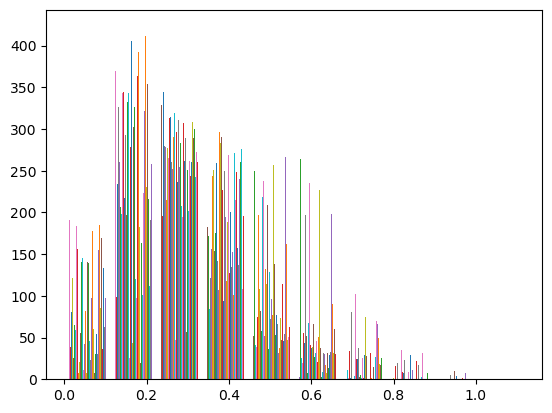

In [14]:
pairwise_distances = torch.cdist(X, X, p=2)
plt.hist(pairwise_distances)

In [33]:
d0 = torch.mean(pairwise_distances)
d0

tensor(0.3056, dtype=torch.float64)

In [31]:
(0.8 * d0, 1.25 * d0)

(tensor(0.2445, dtype=torch.float64), tensor(0.3820, dtype=torch.float64))

## Testing on Hattie data

In [108]:
import torch
import numpy as np
import matplotlib.pyplot as plt

# Define the test function
def spatial_dependence_test(X, Y, gene_index, counts=200, threshold=0.5):
    """
    Perform a nonparametric permutation test for spatial dependence range.

    Parameters:
        X: torch.Tensor, shape (n_samples, 2), spatial coordinates.
        Y: torch.Tensor, shape (n_samples, n_genes), response values for genes.
        gene_index: int, index of the gene to analyze.
        counts: int, number of permutations.
        threshold: float, distance threshold for C_mask.
    
    Returns:
        dict: Dictionary containing test result and additional metrics.
    """
    # Select the response for the specified gene
    Z = Y[:, gene_index]

    # Compute all pairwise distances
    pairwise_distances = torch.cdist(X, X, p=2)
    
    # Compute (Z_i - Z_j)^2 for all pairs
    Z_diff_sq = (Z.unsqueeze(0) - Z.unsqueeze(1))**2
    d0 = torch.mean(pairwise_distances)

    # Define set C
    C_mask = (pairwise_distances > threshold)
    C = Z_diff_sq[C_mask]
    
    # Compute the test statistic t
    t = torch.mean(C)

    # Permutation test
    t_permutations = []
    for _ in range(counts):
        permuted_indices = torch.randperm(X.size(0))  # Random permutation of indices
        X_permuted = X[permuted_indices]  # Shuffle X
        pairwise_distances_perm = torch.cdist(X_permuted, X_permuted, p=2)
        C_mask_perm = (pairwise_distances_perm > threshold)
        C_perm = Z_diff_sq[C_mask_perm]
        t_perm = torch.mean(C_perm)
        t_permutations.append(t_perm.item())

    # Compute the percentile of t among t_permutations
    t_permutations = np.array(t_permutations)
    percentile = np.sum(t_permutations < t.item()) / counts

    # Check for evidence of correlation range above the threshold
    test_result = percentile >= 0.05

    return {
        "test_result": test_result,
        "percentile": percentile,
        "observed_t": t.item(),
        "t_permutations": t_permutations
    }


# Output test results for each gene
def output_test_results(X, Y, counts=200, threshold=0.5):
    """
    Output test results for each gene.

    Parameters:
        X: torch.Tensor, spatial coordinates.
        Y: torch.Tensor, response values.
        counts: int, number of permutations.
        threshold: float, distance threshold for the test.

    Returns:
        None (prints test results for each gene).
    """
    n_genes = Y.shape[1]
    for gene_index in range(n_genes):
        result = spatial_dependence_test(X, Y, gene_index, counts, threshold)
        print(f"Gene {gene_index}: Test Result = {'Retain Null' if result['test_result'] else 'Reject Null'}")
        print(f"  Percentile: {result['percentile']:.2f}")
        print(f"  Observed t: {result['observed_t']:.2f}")

# Example usage
output_test_results(X, Y, counts=200, threshold=0.9)

Gene 0: Test Result = Reject Null
  Percentile: 0.00
  Observed t: 0.19
Gene 1: Test Result = Retain Null
  Percentile: 0.12
  Observed t: 0.29
Gene 2: Test Result = Retain Null
  Percentile: 0.06
  Observed t: 0.40
Gene 3: Test Result = Reject Null
  Percentile: 0.02
  Observed t: 0.36


## Synthetic Data with Spherical Covariance Function

In [94]:
# Define the spherical covariance function
def spherical_covariance(d, range_param):
    """
    Spherical covariance function.
    
    Parameters:
        d: torch.Tensor, pairwise distances.
        range_param: float, correlation range.
    
    Returns:
        torch.Tensor, covariance matrix.
    """
    cov = torch.zeros_like(d)
    mask = d < range_param
    cov[mask] = 1 - 1.5 * (d[mask] / range_param) + 0.5 * (d[mask] / range_param) ** 3
    return cov

# Generate synthetic data
def generate_synthetic_data(n_samples=100, range_param=0.5):
    """
    Generate synthetic data using a Gaussian process with spherical covariance.
    
    Parameters:
        n_samples: int, number of spatial locations.
        range_param: float, correlation range.
    
    Returns:
        X: torch.Tensor, spatial coordinates.
        Y: torch.Tensor, response values.
    """
    # Generate spatial coordinates (2D grid)
    X = torch.rand(n_samples, 2)

    # Compute pairwise distances
    pairwise_distances = torch.cdist(X, X, p=2)
    
    # Compute covariance matrix
    covariance_matrix = spherical_covariance(pairwise_distances, range_param)
    covariance_matrix = (covariance_matrix + covariance_matrix.T)/2

    # Sample from multivariate normal distribution
    L = torch.linalg.cholesky(covariance_matrix + 1e-6 * torch.eye(n_samples))  # Add nugget for numerical stability
    Y = L @ torch.randn(n_samples, 1)  # Single response variable
    
    return X, Y

# Estimate Type I and Type II error rates
def estimate_error_rates(n_runs=100, n_samples=100, test_threshold=0.5):
    """
    Estimate Type I and Type II error rates of the test.

    Parameters:
        n_runs: int, number of simulations.
        n_samples: int, number of spatial locations per simulation.
        test_threshold: float, distance threshold for the test.

    Returns:
        None (prints error rates).
    """
    type_I_errors = 0
    type_II_errors = 0

    for _ in range(n_runs):
        # Generate true range uniformly in [0, 1]
        true_range = np.random.uniform(0, 1)

        # Generate synthetic data
        X, Y = generate_synthetic_data(n_samples, range_param=true_range)

        # Run the test
        result = spatial_dependence_test(X, Y, gene_index=0, counts=200, threshold=test_threshold)

        test_result = result["test_result"]

        # Type I error: Reject null when true_range < test_threshold
        if true_range < test_threshold and not test_result:
            type_I_errors += 1

        # Type II error: Fail to reject null when true_range >= test_threshold
        if true_range >= test_threshold and test_result:
            type_II_errors += 1

    # Compute error rates
    type_I_rate = type_I_errors / n_runs
    type_II_rate = type_II_errors / n_runs

    print(f"Type I Error Rate: {type_I_rate:.2f}")
    print(f"Type II Error Rate: {type_II_rate:.2f}")

estimate_error_rates(n_runs=1000, n_samples=100, test_threshold=0.5)

Type I Error Rate: 0.03
Type II Error Rate: 0.50


In [97]:
# Test local spatial autocorrelation
def local_spatial_autocorrelation(X, Y, gene_index):
    """
    Compute local spatial autocorrelation (e.g., Getis-Ord Gi*).

    Parameters:
        X: torch.Tensor, spatial coordinates.
        Y: torch.Tensor, response values for genes.
        gene_index: int, index of the gene to analyze.

    Returns:
        torch.Tensor: Local spatial autocorrelation values.
    """
    Z = Y[:, gene_index]
    pairwise_distances = torch.cdist(X, X, p=2)
    weights = torch.exp(-pairwise_distances)  # Gaussian kernel weights
    local_autocorrelation = torch.sum(weights * Z.unsqueeze(0), dim=1)
    return local_autocorrelation

# Test global spatial autocorrelation
def global_spatial_autocorrelation(X, Y, gene_index):
    """
    Compute global spatial autocorrelation (e.g., Moran's I).

    Parameters:
        X: torch.Tensor, spatial coordinates.
        Y: torch.Tensor, response values for genes.
        gene_index: int, index of the gene to analyze.

    Returns:
        float: Moran's I value.
    """
    Z = Y[:, gene_index]
    pairwise_distances = torch.cdist(X, X, p=2)
    weights = torch.exp(-pairwise_distances)  # Gaussian kernel weights
    n = Z.size(0)
    W = torch.sum(weights)
    Z_mean = torch.mean(Z)
    Z_diff = Z - Z_mean
    numerator = torch.sum(weights * Z_diff.unsqueeze(0) * Z_diff.unsqueeze(1))
    denominator = torch.sum(Z_diff ** 2)
    morans_I = (n / W) * (numerator / denominator)
    return morans_I
    
local_autocorr = local_spatial_autocorrelation(X, Y, gene_index)
global_autocorr = global_spatial_autocorrelation(X, Y, gene_index)
print(f"Local Spatial Autocorrelation (first 5 values): {local_autocorr[:5]}")
print(f"Global Spatial Autocorrelation (Moran's I): {global_autocorr:.4f}")

Local Spatial Autocorrelation (first 5 values): tensor([203.0832, 211.3420, 201.4001, 194.2072, 197.6118], dtype=torch.float64)
Global Spatial Autocorrelation (Moran's I): 0.0005


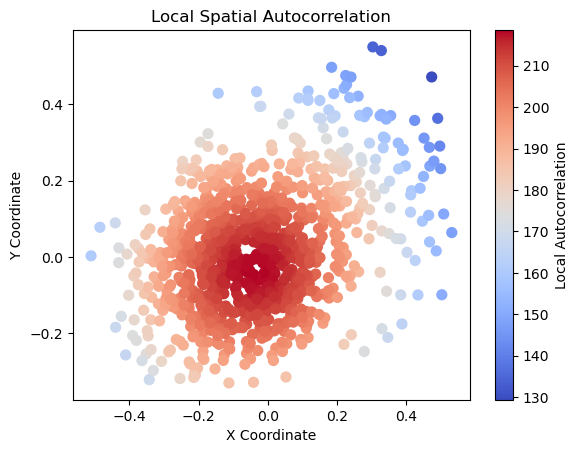

Moran's I: 0.0005, p-value: 0.1700
Moran's I: 0.0007, p-value: 0.0000
Moran's I: 0.0005, p-value: 0.1300
Moran's I: 0.0005, p-value: 0.1400
High Local Autocorrelation Regions (Coordinates):
tensor([[-0.0027,  0.1572],
        [-0.1689, -0.0034],
        [-0.1781,  0.1174],
        ...,
        [ 0.2176,  0.3275],
        [-0.2231, -0.1620],
        [-0.0914, -0.0206]], dtype=torch.float64)


In [99]:
# Visualization: Plot local spatial autocorrelation
def plot_local_autocorrelation(X, local_autocorr):
    """
    Visualize local spatial autocorrelation values spatially.

    Parameters:
        X: torch.Tensor, spatial coordinates.
        local_autocorr: torch.Tensor, local spatial autocorrelation values.

    Returns:
        None.
    """
    plt.scatter(X[:, 0].numpy(), X[:, 1].numpy(), c=local_autocorr.numpy(), cmap='coolwarm', s=50)
    plt.colorbar(label='Local Autocorrelation')
    plt.xlabel('X Coordinate')
    plt.ylabel('Y Coordinate')
    plt.title('Local Spatial Autocorrelation')
    plt.show()

# Significance testing for Moran's I
def morans_I_significance_test(X, Y, gene_index, num_permutations=100):
    """
    Perform a permutation test for Moran's I significance.

    Parameters:
        X: torch.Tensor, spatial coordinates.
        Y: torch.Tensor, response values for genes.
        gene_index: int, index of the gene to analyze.
        num_permutations: int, number of random permutations.

    Returns:
        tuple: Moran's I value, p-value.
    """
    observed_I = global_spatial_autocorrelation(X, Y, gene_index)
    permuted_I = []

    for _ in range(num_permutations):
        permuted_indices = torch.randperm(Y.size(0))
        permuted_Y = Y[permuted_indices, gene_index]
        permuted_I.append(global_spatial_autocorrelation(X, permuted_Y.unsqueeze(1), 0))

    permuted_I = torch.tensor(permuted_I)
    p_value = torch.mean((permuted_I >= observed_I).float()).item()

    return observed_I, p_value

# Further analysis of high local autocorrelation regions
def analyze_high_autocorr_regions(X, local_autocorr, threshold=1.5):
    """
    Analyze regions with high local spatial autocorrelation.

    Parameters:
        X: torch.Tensor, spatial coordinates.
        local_autocorr: torch.Tensor, local spatial autocorrelation values.
        threshold: float, threshold to define high autocorrelation.

    Returns:
        torch.Tensor: Coordinates of high autocorrelation regions.
    """
    high_autocorr_indices = (local_autocorr > threshold).nonzero(as_tuple=True)[0]
    high_autocorr_coords = X[high_autocorr_indices]
    return high_autocorr_coords


# Visualization
plot_local_autocorrelation(X, local_autocorr)

# Significance testing
for gene_index in range(4):
    observed_I, p_value = morans_I_significance_test(X, Y, gene_index)
    print(f"Moran's I: {observed_I:.4f}, p-value: {p_value:.4f}")
    
# Further analysis
high_autocorr_coords = analyze_high_autocorr_regions(X, local_autocorr)
print(f"High Local Autocorrelation Regions (Coordinates):\n{high_autocorr_coords}")


## (obsolete) Divide bins according to percentiles

In [9]:
import torch
import numpy as np

# Partition domain and test for teleconnection
def teleconnection_test(X, Y, num_partitions=4, num_permutations=100):
    """
    Partition the domain into local subsets and test for teleconnection.

    Parameters:
        X: torch.Tensor, spatial coordinates.
        Y: torch.Tensor, response values for genes.
        num_partitions: int, number of partitions for the domain.
        num_permutations: int, number of permutations for significance testing.

    Returns:
        dict: Results containing test statistics and p-values for teleconnection.
    """
    # Step 1: Partition the domain
    n_samples = X.size(0)
    partition_labels = torch.randint(0, num_partitions, (n_samples,))

    # Step 2: Compute regional means
    regional_means = []
    for i in range(num_partitions):
        region_indices = (partition_labels == i).nonzero(as_tuple=True)[0]
        if len(region_indices) > 0:
            regional_means.append(torch.mean(Y[region_indices], dim=0))
        else:
            regional_means.append(torch.zeros(Y.size(1), dtype=Y.dtype))
    regional_means = torch.stack(regional_means)

    # Step 3: Fit linear models to test teleconnection
    test_statistics = []
    for i in range(num_partitions):
        predictor_indices = [j for j in range(num_partitions) if j != i]
        predictors = regional_means[predictor_indices]
        target = regional_means[i]

        # Solve linear regression using least squares
        if predictors.size(0) > 0 and predictors.size(1) == target.size(0):
            predictors_with_intercept = torch.cat([predictors, torch.ones((predictors.size(0), 1))], dim=1)
            lstsq_result = torch.linalg.lstsq(predictors_with_intercept, target.unsqueeze(1))
            coefficients = lstsq_result.solution
            predicted = (predictors_with_intercept @ coefficients).squeeze()
            residuals = target - predicted
            mse = torch.mean(residuals ** 2)
        else:
            mse = float('nan')  # Handle edge cases where predictors or target have mismatched dimensions
        test_statistics.append(mse)

    # Step 4: Permutation testing
    p_values = []
    for i in range(num_partitions):
        observed_stat = test_statistics[i]
        if torch.isnan(observed_stat):
            p_values.append(float('nan'))
            continue
        permuted_stats = []
        for _ in range(num_permutations):
            permuted_labels = partition_labels[torch.randperm(n_samples)]
            permuted_means = []
            for j in range(num_partitions):
                region_indices = (permuted_labels == j).nonzero(as_tuple=True)[0]
                if len(region_indices) > 0:
                    permuted_means.append(torch.mean(Y[region_indices], dim=0))
                else:
                    permuted_means.append(torch.zeros(Y.size(1), dtype=Y.dtype))
            permuted_means = torch.stack(permuted_means)

            predictors = permuted_means[predictor_indices]
            target = permuted_means[i]
            if predictors.size(0) > 0 and predictors.size(1) == target.size(0):
                predictors_with_intercept = torch.cat([predictors, torch.ones((predictors.size(0), 1))], dim=1)
                lstsq_result = torch.linalg.lstsq(predictors_with_intercept, target.unsqueeze(1))
                coefficients = lstsq_result.solution
                predicted = (predictors_with_intercept @ coefficients).squeeze()
                residuals = target - predicted
                mse = torch.mean(residuals ** 2)
                permuted_stats.append(mse.item())

        if len(permuted_stats) > 0:
            permuted_stats = torch.tensor(permuted_stats)
            p_value = torch.mean((permuted_stats <= observed_stat).float()).item()
        else:
            p_value = float('nan')  # Handle edge cases
        p_values.append(p_value)

    # Step 5: Compile results
    results = {
        "test_statistics": test_statistics,
        "p_values": p_values
    }
    return results

# Example usage
if __name__ == "__main__":
    # Generate synthetic data for demonstration
    def generate_synthetic_data(n_samples=100, range_param=0.5):
        """
        Generate synthetic data using a Gaussian process with spherical covariance.
        
        Parameters:
            n_samples: int, number of spatial locations.
            range_param: float, correlation range.
        
        Returns:
            X: torch.Tensor, spatial coordinates.
            Y: torch.Tensor, response values.
        """
        X = torch.rand(n_samples, 2)  # Random spatial coordinates
        pairwise_distances = torch.cdist(X, X, p=2)
        covariance_matrix = torch.exp(-pairwise_distances / range_param)  # Exponential covariance
        L = torch.linalg.cholesky(covariance_matrix + 1e-6 * torch.eye(n_samples))  # Add stability term
        Y = L @ torch.randn(n_samples, 1)  # Sample synthetic gene expression data
        return X, Y

    # Perform teleconnection test
    results = teleconnection_test(X, Y, num_partitions=4, num_permutations=100)
    print("Test Statistics:", results["test_statistics"])
    print("P-Values:", results["p_values"])


RuntimeError: torch.linalg.lstsq: input.size(-2) should match other.size(-2)

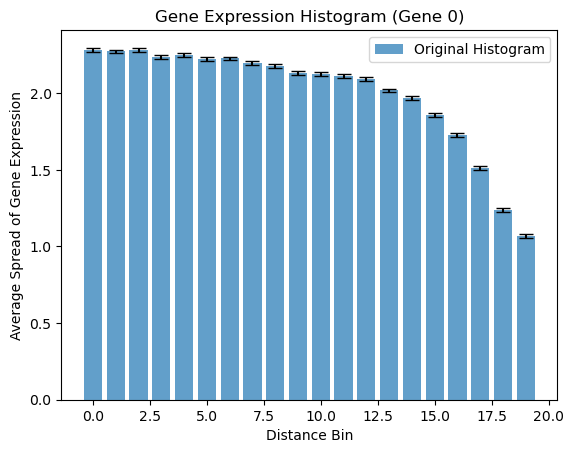

Original Histogram Sample Variance: 0.1242
Bootstrap Variances Mean: 0.0119
Bootstrap Variances Std: 0.0145
Percentile of Original Variance Among Bootstrap Samples: 100.00%
Statistical evidence for spatial dependence (percentile > 95%).


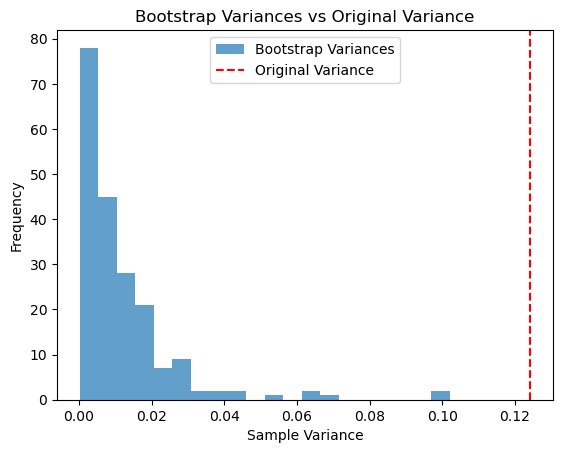

Time taken: 16.456117 minutes


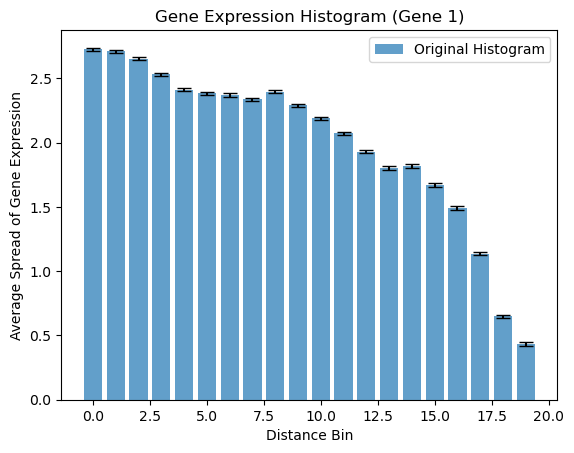

Original Histogram Sample Variance: 0.4245
Bootstrap Variances Mean: 0.0935
Bootstrap Variances Std: 0.1307
Percentile of Original Variance Among Bootstrap Samples: 96.50%
Statistical evidence for spatial dependence (percentile > 95%).


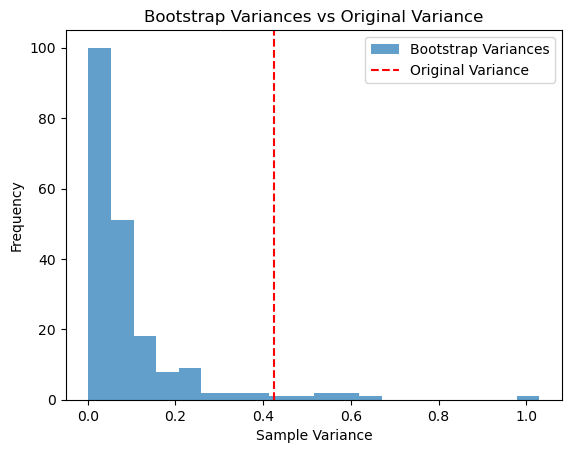

Time taken: 16.390614 minutes


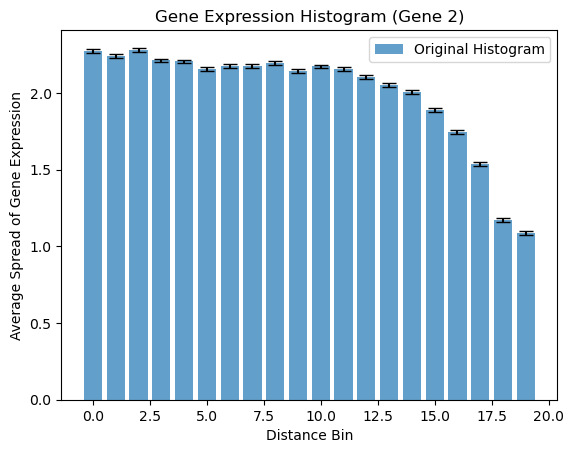

Original Histogram Sample Variance: 0.1227
Bootstrap Variances Mean: 0.0412
Bootstrap Variances Std: 0.0653
Percentile of Original Variance Among Bootstrap Samples: 95.00%


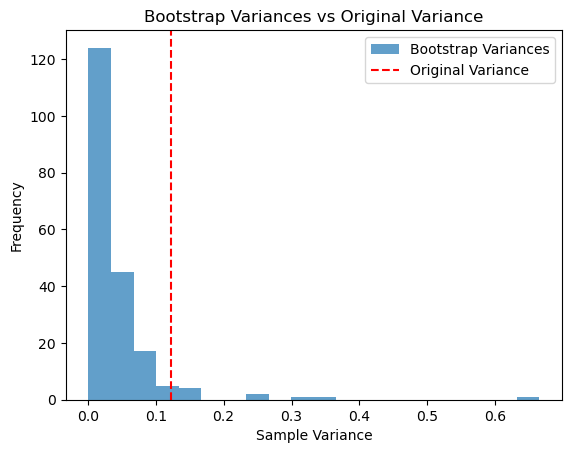

Time taken: 16.374922 minutes


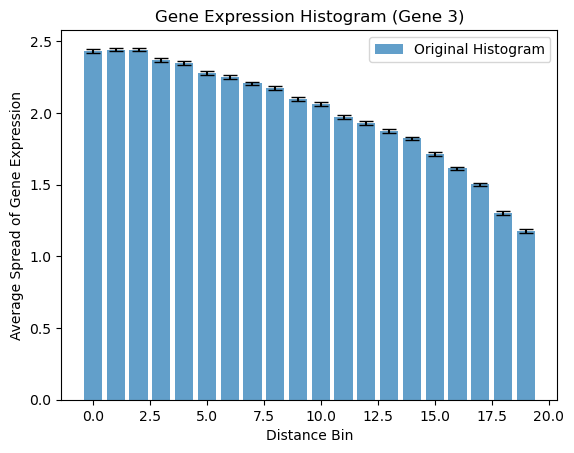

In [ ]:
# import time
# import torch
# import numpy as np
# import matplotlib.pyplot as plt
# from scipy.spatial.distance import pdist

# # Function to compute pairwise distances and bin data
# def compute_histogram_variance(X, gene_expression, num_bins=10):
#     # Compute pairwise distances using pdist
#     pairwise_distances = pdist(X, metric="euclidean")

#     # Flatten gene expression differences (no duplicate pairs)
#     gene_differences = []
#     for i in range(len(gene_expression)):
#         for j in range(i + 1, len(gene_expression)):
#             gene_differences.append(abs(gene_expression[i] - gene_expression[j])**2)
#     gene_differences = np.array(gene_differences)

#     # Bin the distances using the empirical distribution
#     sorted_distances = np.sort(pairwise_distances)
#     bin_edges = [np.percentile(sorted_distances, 100 * i / num_bins) for i in range(num_bins + 1)]
#     bin_indices = np.digitize(pairwise_distances, bin_edges) - 1  # Bin indices (0 to num_bins-1)

#     # Compute average spread of gene expression values in each bin
#     histogram = []
#     bin_counts = []
#     for i in range(num_bins):
#         bin_mask = bin_indices == i
#         bin_count = bin_mask.sum()
#         if bin_count > 0:
#             histogram.append(gene_differences[bin_mask].mean())
#         else:
#             histogram.append(0)  # Handle empty bins
#         bin_counts.append(bin_count)

#     # Compute sample variance of the histogram
#     histogram = np.array(histogram)
#     bin_counts = np.array(bin_counts)
#     sample_variance = np.var(histogram, ddof=1)  # Sample variance

#     return histogram, sample_variance, bin_counts

# # Bootstrapping step
# def bootstrap_variance(X, gene_expression, B=200, num_bins=10):
#     bootstrap_variances = []

#     for _ in range(B):
#         # Randomly permute spatial locations
#         permuted_X = X[torch.randperm(X.size(0))]

#         # Compute sample variance for permuted data
#         _, sample_variance, _ = compute_histogram_variance(permuted_X, gene_expression, num_bins)
#         bootstrap_variances.append(sample_variance)

#     return bootstrap_variances

# # Main functionality
# def analyze_gene_expression(X, Y, gene_index, B=200, num_bins=10):
#     gene_expression = Y[:, gene_index].numpy()  # Select the chosen gene's expression

#     # Original histogram and sample variance
#     original_histogram, original_variance, bin_counts = compute_histogram_variance(X, gene_expression, num_bins)

#     # Compute yerr as square root of bin counts
#     yerr = 10/np.sqrt(bin_counts)

#     # Plot histogram with error bars
#     plt.bar(range(num_bins), original_histogram, yerr=yerr, capsize=5, alpha=0.7, label="Original Histogram")
#     plt.xlabel("Distance Bin")
#     plt.ylabel("Average Spread of Gene Expression")
#     plt.title(f"Gene Expression Histogram (Gene {gene_index})")
#     plt.legend()
#     plt.show()

#     # Bootstrap sample variances
#     bootstrap_variances = bootstrap_variance(X, gene_expression, B, num_bins)

#     # Compare original variance with bootstrap variances
#     percentile = np.sum(np.array(bootstrap_variances) < original_variance) / B * 100
#     print(f"Original Histogram Sample Variance: {original_variance:.4f}")
#     print(f"Bootstrap Variances Mean: {np.mean(bootstrap_variances):.4f}")
#     print(f"Bootstrap Variances Std: {np.std(bootstrap_variances):.4f}")
#     print(f"Percentile of Original Variance Among Bootstrap Samples: {percentile:.2f}%")

#     if percentile > 95:
#         print("Statistical evidence for spatial dependence (percentile > 95%).")

#     # Plot comparison
#     plt.hist(bootstrap_variances, bins=20, alpha=0.7, label="Bootstrap Variances")
#     plt.axvline(original_variance, color="red", linestyle="--", label="Original Variance")
#     plt.xlabel("Sample Variance")
#     plt.ylabel("Frequency")
#     plt.legend()
#     plt.title("Bootstrap Variances vs Original Variance")
#     plt.show()

# # Example usage: Analyze the first gene (index 0)
# for gene_index in range(4):
#     start_time = time.time()
#     analyze_gene_expression(X, Y, gene_index, B=200, num_bins=20)
#     end_time = time.time()
#     elapsed_time =(end_time - start_time)/60
#     print(f"Time taken: {elapsed_time:.6f} minutes")
